# Data retrieval

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv(r'student_performance.csv')
df

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13998,30,62,0,1,1,1,0,22,2,2,1,100,71,1,2,1
13999,30,62,0,1,1,1,0,23,3,12,1,72,55,1,1,2
14000,22,90,2,0,1,1,0,23,3,0,1,80,56,0,0,2
14001,22,90,2,0,1,1,0,29,2,16,0,50,62,1,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  int64
dtypes: i

In [4]:
X = df[['StudyHours', 'OnlineCourses', 'AssignmentCompletion']]

# Data cleaning

### Duplicates

In [5]:
df.duplicated().sum()

np.int64(1534)

In [6]:
df.drop_duplicates(inplace=True)

### Elbow curve

In [7]:
def opt_k(data, max_k):
    kvalues = []
    inertias = []

    for k in range(1, max_k):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(data)
        kvalues.append(k)
        inertias.append(kmeans.inertia_)

    fig = plt.subplots(figsize=(10,5))
    # 'o-' tells the interpreter the points shud be marked o
    plt.plot(kvalues, inertias, 'o-')
    plt.xlabel('Number od clusters')
    plt.ylabel('Inertia')
    plt.grid(True)
    plt.show()

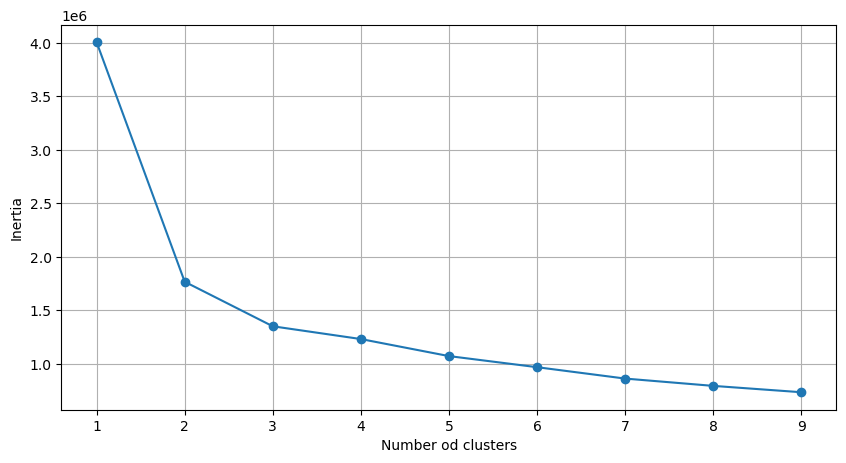

In [8]:
opt_k(X, 10)

### Silhouette curve

In [9]:
def sil_score(data, max_k):
    sil = []

    # Silhouette needs 2 clusters minimum
    for k in range(2, max_k+1):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(data)
        sil.append(silhouette_score(data, kmeans.labels_))

    fig = plt.subplots(figsize=(10, 5))
    plt.plot(range(2, max_k+1), sil, 'x-')
    plt.xlabel('Number of clusters')
    plt.ylabel('Silhouette')
    plt.grid(True)
    plt.show()

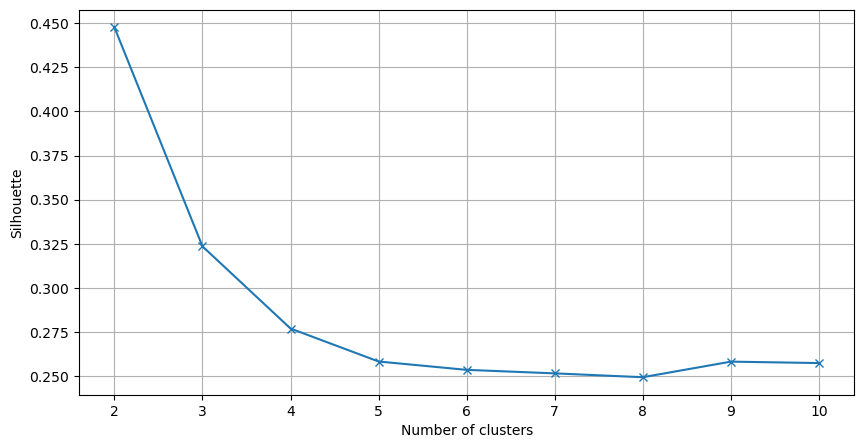

In [10]:
sil_score(X, 10)

In [11]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [12]:
X['Labels'] = kmeans.labels_

C:\Users\User\AppData\Local\Temp\ipykernel_16088\3977979570.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Labels'] = kmeans.labels_


In [13]:
X

,StudyHours,OnlineCourses,AssignmentCompletion,Labels
0,19,8,59,2
1,19,16,90,1
2,19,19,67,0
3,19,8,59,2
4,19,16,90,1
...,...,...,...,...
13998,30,2,100,1
13999,30,12,72,0
14000,22,0,80,0
14001,22,16,50,2


In [14]:
import plotly.express as px

In [29]:
fig = px.scatter_3d(
    x='StudyHours',
    y='OnlineCourses',
    z='AssignmentCompletion',
    data_frame=X,
    color='Labels',
    width=800,
    height=1000
)

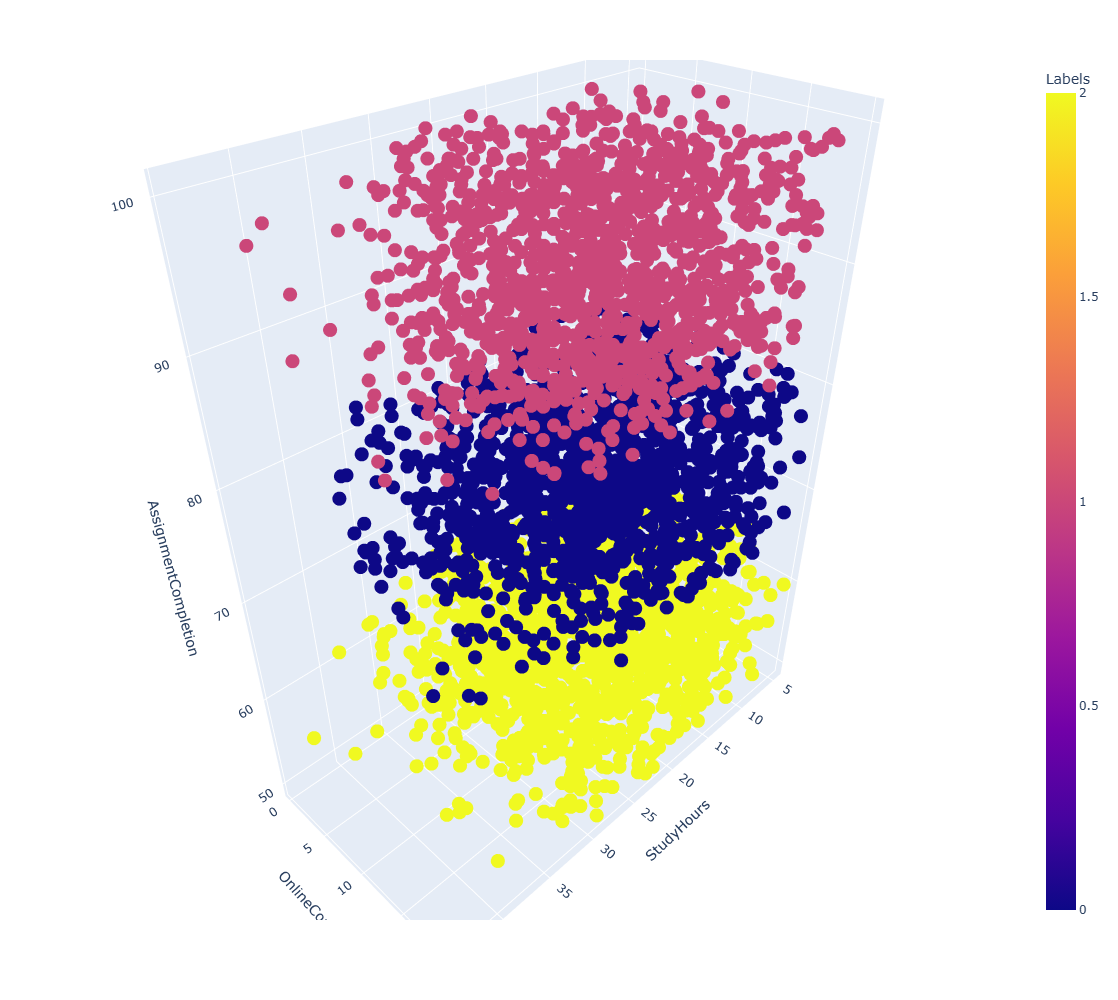

In [32]:
fig.show()